**420-C74-SF - Techniques d'apprentissage automatique - Automne 2026 - Spécialiste en solutions d'intelligence artificielle**<br/>
© 2026 MKL.AI - Tous droits réservés
<br/>
![Atelier - Régression linéaire simple](static/02-A-banner.png)
<br/>
**Objectif:** cette séance de travaux pratiques propose la résolution **analytique** d'une régression linéaire simple par la **méthode des moindres carrés**. Contrairement à l'algorithme du gradient (chapitre 03), les paramètres du modèle sont ici obtenus par un **calcul direct, sans aucune itération**. Le jeu de données utilisé sera la version simplifiée (une seule variable) du jeu de données *Advertising*

In [30]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

### 0 - Chargement des bibliothèques

In [31]:
# Manipulation de données
import numpy as np
import pandas as pd

# Visualisation de données
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
# Configuration de la visualisation
sns.set_theme(style="darkgrid", rc={'figure.figsize':(11.7,8.27)})

### 1 - Lecture du jeu de données advertising

**Exercice 1-1**: à l'aide de la bibliothèque *pandas*, lire le fichier `advertising-univariate.csv`

In [33]:
# Compléter le code ci-dessous ~ 1 ligne
df = pd.read_csv("/notebooks/data/advertising-univariate.csv")

**Exercice 1-2**: à l'aide de la fonction `head()`, visualiser les premières lignes de la trame de données

In [34]:
# Compléter le code ci-dessous ~ 1 ligne
df.head()

,TV,sales
0,230.1,22.1
1,44.5,10.4
2,17.2,9.3
3,151.5,18.5
4,180.8,12.9


**Exercice 1-3**: combien d'observations le jeu de données contient-il ? Affecter cette valeur à la variable `m`

In [35]:
# Compléter le code ci-dessous ~ 1 ligne
m = len(df)

print(f'Nombre d\'observations: {m}')

Nombre d'observations: 200


<strong style='color: green'>TEST - Le code ci-dessous vous permet de tester votre réponse. Le `assert` ne doit pas renvoyer d'exception</strong>

In [36]:
assert m == 200 #ajuste le 200 tu va avoir une valeur fausse ! donc, il doit concorder avec la valeur len(df) sorti plus haut (exercice 1-3)

### 2 - Préparation de la structure de données

**Exercice 2**: construire les deux tableaux *numpy* `x` (budget de publicité TV) et `y` (ventes) à partir de la trame de données

Note: contrairement à l'atelier du chapitre 03, aucune mise à l'échelle n'est appliquée ici. Les budgets sont donc exprimés en milliers d'USD.

<details>
<summary>
    <font size="3" color="darkgreen"><b>Cliquer ici pour obtenir un indice</b></font>
</summary>
<p>
L'attribut <code>.values</code> d'une colonne de trame de données renvoie un tableau <em>numpy</em>.
</p>
</details>

In [37]:
# Compléter le code ci-dessous ~ 2 lignes
x = df['TV'].values
y = df['sales'].values

<strong style='color: green'>TEST - Le code ci-dessous vous permet de tester votre réponse. Le `assert` ne doit pas renvoyer d'exception</strong>

In [38]:
assert x.shape == (200,)
assert y.shape == (200,)

### 3 - Visualisation des données

La cellule ci-dessous affiche le nuage de points. Chaque point représente un marché: son budget de publicité TV et les ventes observées

Text(0, 0.5, "Ventes (en millier d'unités)")

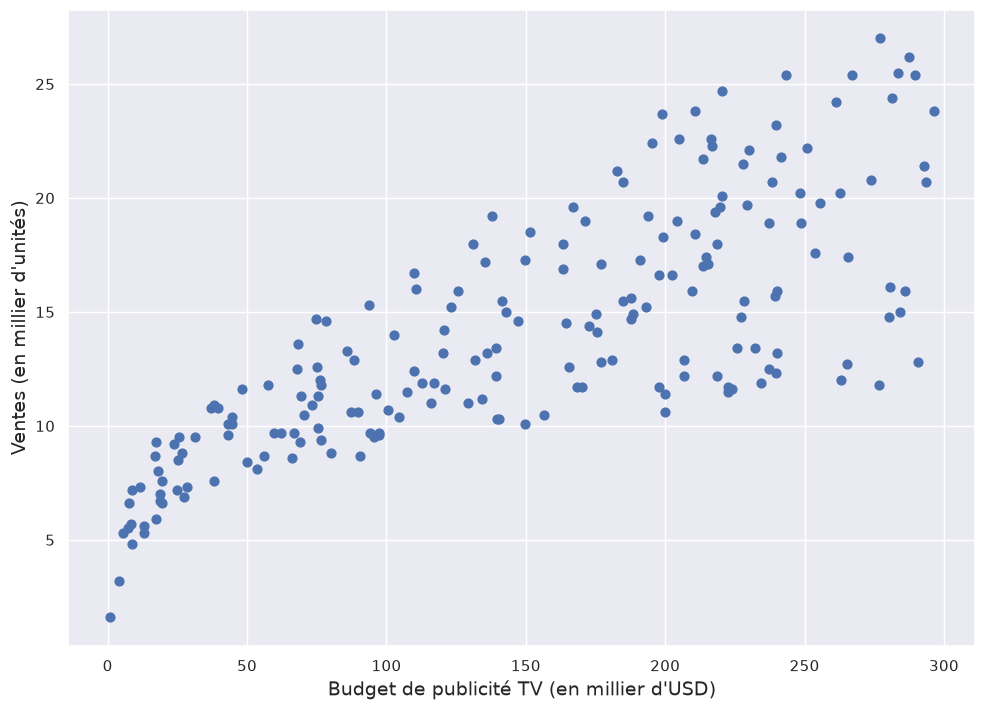

In [39]:
fig, ax = plt.subplots()
ax.scatter(x, y, s=40)
ax.set_xlabel("Budget de publicité TV (en millier d'USD)", fontsize=14)
ax.set_ylabel("Ventes (en millier d'unités)", fontsize=14)

**Question**: la relation entre le budget de publicité TV et les ventes vous semble-t-elle pouvoir être approchée par une droite ?

reponse : Oui une ligne droite

### 4 - Définition du modèle (hypothèse)

**Exercice 3**: compléter la fonction ci-dessous représentant le modèle de régression linéaire simple (hypothèse)

<details>
<summary>
    <font size="3" color="darkgreen"><b>Cliquer ici pour obtenir un indice</b></font>
</summary>
<p>
Pour rappel, le modèle de régression linéaire simple est
$h_{\theta}(x)=\theta_{0} + \theta_{1}x$
</p>
</details>

In [40]:
def hypothesis(x, theta_0, theta_1):
    # Compléter le code ci-dessous ~ 1 ligne
    h = theta_0+theta_1*x
    return h

    

<strong style='color: green'>TEST - Le code ci-dessous vous permet de tester votre réponse. Le `assert` ne doit pas renvoyer d'exception</strong>

In [41]:
assert np.allclose(hypothesis(np.array([0.0, 1.0, 2.0]), 1.0, 2.0), np.array([1.0, 3.0, 5.0]))

### 5 - Résidus et somme des carrés des résidus

Le **résidu** est l'écart vertical entre une observation et la droite:

$e^{(i)} = y^{(i)} - h_{\theta}(x^{(i)})$

On élève au carré chaque résidu, puis on les additionne. Le carré évite l'annulation des signes et pénalise les grands écarts. La quantité à minimiser est la **somme des carrés des résidus** (*residual sum of squares*):

$\text{RSS}(\theta_{0},\theta_{1}) = \sum\limits_{i=1}^{m}\left(y^{(i)} - h_{\theta}(x^{(i)})\right)^{2}$

**Exercice 4**: compléter la fonction ci-dessous permettant le calcul des résidus

In [42]:
def residuals(x, y, theta_0, theta_1):
    assert len(x) == len(y)
    # Compléter le code ci-dessous ~ 1 ligne
    e = y-hypothesis(x, theta_0, theta_1)
    return e

<strong style='color: green'>TEST - Le code ci-dessous vous permet de tester votre réponse. Le `assert` ne doit pas renvoyer d'exception</strong>

In [43]:
assert np.allclose(
    residuals(np.array([0.0, 1.0, 2.0]), np.array([1.0, 2.0, 7.0]), 1.0, 2.0),
    np.array([0.0, -1.0, 2.0])
)

**Exercice 5**: compléter la fonction ci-dessous permettant le calcul de la somme des carrés des résidus

<details>
<summary>
    <font size="3" color="darkgreen"><b>Cliquer ici pour obtenir un indice</b></font>
</summary>
<p>
Les fonctions <code>np.sum</code> et l'opérateur <code>**</code> suffisent.
</p>
</details>

In [121]:
def rss(x, y, theta_0, theta_1):
    # Compléter le code ci-dessous ~ 1 ligne
    s = np.sum(residuals(x, y, theta_0, theta_1)**2)
    return s

<strong style='color: green'>TEST - Le code ci-dessous vous permet de tester votre réponse. Le `assert` ne doit pas renvoyer d'exception</strong>

In [122]:
assert np.isclose(rss(np.array([0.0, 1.0, 2.0]), np.array([1.0, 2.0, 7.0]), 1.0, 2.0), 5.0)

### 6 - Ajustement manuel des paramètres

**Exercice 6**: avant de passer au calcul direct, faites varier à la main $\theta_{0}$ et $\theta_{1}$ de manière à obtenir le meilleur ajustement possible. Le titre du graphique affiche le RSS correspondant: cherchez à le rendre le plus petit possible

Notez la valeur du plus petit RSS que vous parvenez à obtenir, elle servira de point de comparaison à la section 7

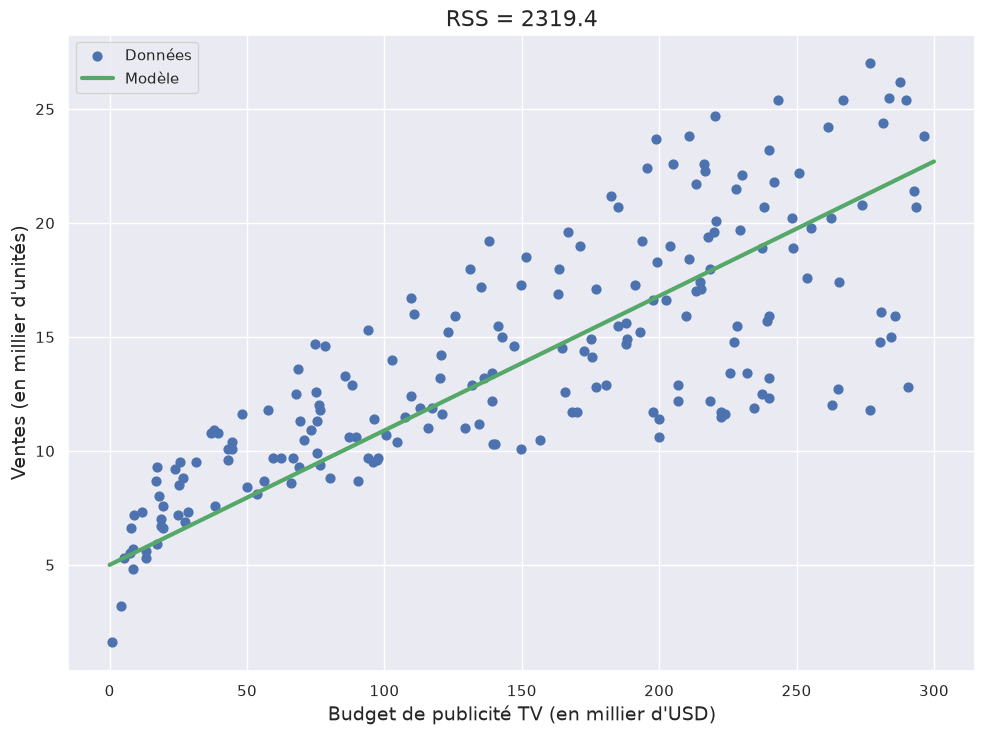

In [147]:
# Faire varier les deux valeurs ci-dessous ~ 2 lignes
theta_0 = 5
theta_1 = 0.059

reg_x = np.linspace(0, 300, 10)
reg_y = hypothesis(reg_x, theta_0, theta_1)

fig, ax = plt.subplots()
ax.scatter(x, y, s=40, label="Données")
ax.plot(reg_x, reg_y, color="g", lw=3, label="Modèle")
ax.set_xlabel("Budget de publicité TV (en millier d'USD)", fontsize=14)
ax.set_ylabel("Ventes (en millier d'unités)", fontsize=14)
ax.set_title(f"RSS = {rss(x, y, theta_0, theta_1):.1f}", fontsize=16)
ax.legend(loc='upper left')

### 7 - La méthode des moindres carrés

Plutôt que de tâtonner, les paramètres qui minimisent le RSS s'obtiennent par un **calcul direct**. En annulant les dérivées partielles du RSS par rapport à $\theta_{0}$ et $\theta_{1}$, on obtient les deux formules des moindres carrés:

$\theta_{1} = \dfrac{\sum\limits_{i=1}^{m}\left(x^{(i)}-\bar{x}\right)\left(y^{(i)}-\bar{y}\right)}{\sum\limits_{i=1}^{m}\left(x^{(i)}-\bar{x}\right)^{2}}
\qquad
\theta_{0} = \bar{y} - \theta_{1}\bar{x}$

où $\bar{x}$ et $\bar{y}$ désignent les moyennes de $x$ et de $y$.

**Aucune itération, aucun pas d'apprentissage: un seul calcul.**

**Exercice 7**: compléter la fonction ci-dessous. Seules les fonctions `np.mean` et `np.sum` sont nécessaires

<details>
<summary>
    <font size="3" color="darkgreen"><b>Cliquer ici pour obtenir un indice</b></font>
</summary>
<p>
<code>x - x_bar</code> soustrait la moyenne à chaque élément du tableau (diffusion). Le produit <code>*</code> entre deux tableaux <em>numpy</em> est un produit terme à terme, il ne reste plus qu'à en faire la somme.
</p>
</details>

In [158]:
def least_squares(x, y):
    assert len(x) == len(y)
    # Compléter le code ci-dessous ~ 4 lignes
    x_bar = np.mean(x) # Moyenne de x
    y_bar = np.mean(y) # Moyenne de y
    theta_1 = np.sum((x - x_bar) * (y - y_bar)) / np.sum((x - x_bar) ** 2) # Pente de la droite de regression
    theta_0 = y_bar - theta_1 * x_bar # Ordonnée à l'origine de la droite de regression
    return theta_0, theta_1

In [159]:
theta_0, theta_1 = least_squares(x, y)

print(f'theta_0 = {theta_0}')
print(f'theta_1 = {theta_1}')

theta_0 = 7.0325935491276965
theta_1 = 0.047536640433019736


Les valeurs obtenues devraient être

```
theta_0 = 7.0325935491...
theta_1 = 0.0475366404...
```

<strong style='color: green'>TEST - Le code ci-dessous vous permet de tester votre réponse. Le `assert` ne doit pas renvoyer d'exception</strong>

In [160]:
assert np.isclose(theta_0, 7.032594)
assert np.isclose(theta_1, 0.047537)

**Exercice 8**: calculer le RSS obtenu avec ces paramètres, et le comparer à celui de votre ajustement manuel (exercice 6)

In [161]:
# Compléter le code ci-dessous ~ 1 ligne
rss_optimal = rss(x, y, theta_0, theta_1)

print(f'RSS (moindres carrés) = {rss_optimal:.2f}')

RSS (moindres carrés) = 2102.53


<strong style='color: green'>TEST - Le code ci-dessous vous permet de tester votre réponse. Le `assert` ne doit pas renvoyer d'exception</strong>

In [162]:
assert np.isclose(rss_optimal, 2102.5306, atol=1e-3)

**Question**: pouvez-vous trouver, en tâtonnant, un couple $(\theta_{0}, \theta_{1})$ donnant un RSS plus faible ?

Non, il n'est pas possible d'obtenir un RSS plus faible que 2102.53 en tâtonnant, car les valeurs obtenues par la méthode des moindres carrés correspondent au minimum mathématique exact de la fonction RSS. C'est la meilleure droite possible pour ces données.

### 8 - Affichage de la droite ajustée

La cellule ci-dessous affiche la droite des moindres carrés ainsi que les résidus (segments verticaux rouges)

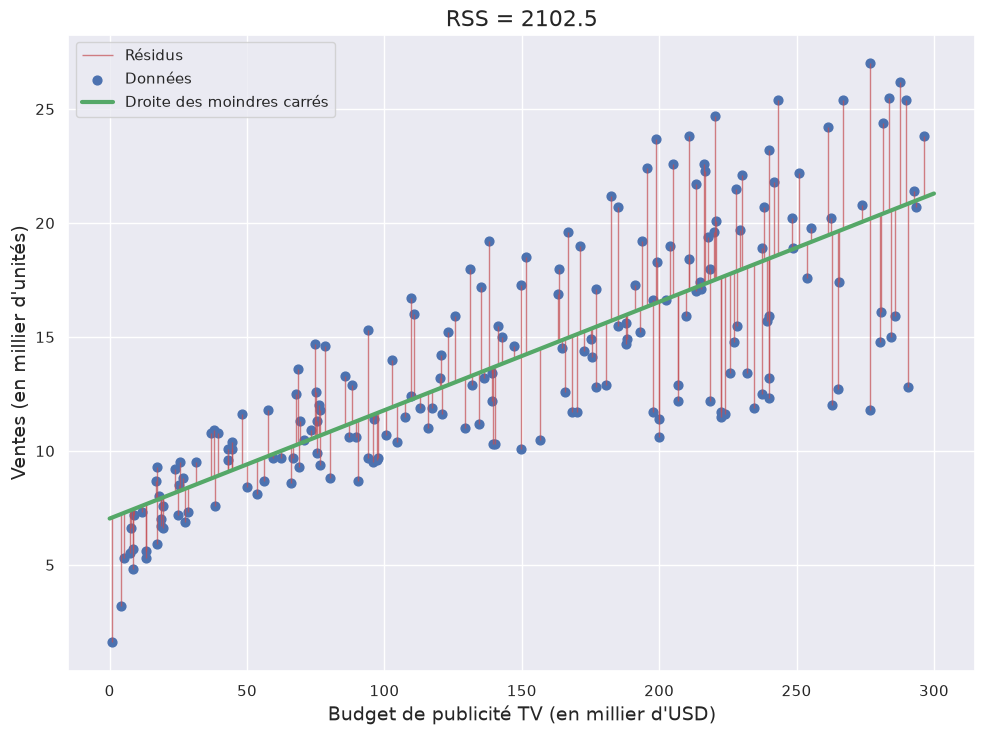

In [165]:
reg_x = np.linspace(0, 300, 10)
reg_y = hypothesis(reg_x, theta_0, theta_1)

fig, ax = plt.subplots()
ax.vlines(x, hypothesis(x, theta_0, theta_1), y, color="r", lw=1, alpha=0.7, label="Résidus")
ax.scatter(x, y, s=40, label="Données")
ax.plot(reg_x, reg_y, color="g", lw=3, label="Droite des moindres carrés")
ax.set_xlabel("Budget de publicité TV (en millier d'USD)", fontsize=14)
ax.set_ylabel("Ventes (en millier d'unités)", fontsize=14)
ax.set_title(f"RSS = {rss(x, y, theta_0, theta_1):.1f}", fontsize=16)
ax.legend(loc='upper left')

### 9 - Prédiction

**Exercice 9**: quelles ventes le modèle prédit-il sur un nouveau marché où le budget de publicité TV serait de 150 milliers d'USD ?

In [166]:
budget = 150

# Compléter le code ci-dessous ~ 1 ligne
ventes_predites = theta_0 + theta_1 * budget

print(f'Ventes prédites: {ventes_predites:.2f} milliers d\'unités')

Ventes prédites: 14.16 milliers d'unités


<strong style='color: green'>TEST - Le code ci-dessous vous permet de tester votre réponse. Le `assert` ne doit pas renvoyer d'exception</strong>

In [169]:
assert np.isclose(ventes_predites, 14.163090, atol=1e-4)

**Attention**: le modèle n'a été ajusté que sur des budgets compris entre `x.min()` et `x.max()`. Une prédiction pour un budget très éloigné de cet intervalle (une **extrapolation**) n'est pas justifiée par les données.

In [171]:
print(f'Domaine observé: de {x.min()} à {x.max()} milliers d\'USD')

Domaine observé: de 0.7 à 296.4 milliers d'USD


### 10 - Interprétation des paramètres

**Exercice 10**: dans le contexte du jeu de données *Advertising*, quelle est l'interprétation concrète de $\theta_{0}$ et de $\theta_{1}$ ? Répondre dans la cellule ci-dessous

*(votre réponse ici)*

Note: l'interprétation de $\theta_{1}$ (et parfois de $\theta_{0}$) est très importante en pratique. Elle dépend des **unités** des variables: si le budget avait été exprimé en centaines de milliers d'USD, comme dans l'atelier du chapitre 03, la valeur de $\theta_{1}$ aurait été multipliée par 100.

### 11 - Vérification

Les formules des moindres carrés peuvent aussi s'écrire à l'aide de la covariance et de la variance:

$\theta_{1} = \dfrac{\text{Cov}(x,y)}{\text{Var}(x)}$

La cellule ci-dessous vérifie que les trois écritures (votre implémentation, la forme covariance/variance et l'ajustement polynomial de degré 1 de *numpy*) donnent bien le même résultat

In [172]:
# Forme covariance / variance
theta_1_cov = np.cov(x, y, ddof=1)[0, 1] / np.var(x, ddof=1)

# Ajustement polynomial de degré 1 (numpy)
theta_0_np, theta_1_np = np.polynomial.Polynomial.fit(x, y, deg=1).convert().coef

print(f'theta_1 (votre implémentation)     = {theta_1}')
print(f'theta_1 (covariance / variance)    = {theta_1_cov}')
print(f'theta_1 (numpy Polynomial.fit)     = {theta_1_np}')
print()
print(f'theta_0 (votre implémentation)     = {theta_0}')
print(f'theta_0 (numpy Polynomial.fit)     = {theta_0_np}')

assert np.isclose(theta_1, theta_1_cov)
assert np.isclose(theta_1, theta_1_np)
assert np.isclose(theta_0, theta_0_np)

theta_1 (votre implémentation)     = 0.047536640433019736
theta_1 (covariance / variance)    = 0.047536640433019736
theta_1 (numpy Polynomial.fit)     = 0.047536640433019715

theta_0 (votre implémentation)     = 7.0325935491276965
theta_0 (numpy Polynomial.fit)     = 7.032593549127696


### Fin de l'atelier